In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

In [2]:
miipa = pd.read_csv('../MI-IPA_results_TPR.csv')
ga = pd.read_csv('../GA_results_TPR.csv')
gamiipa = pd.read_csv('../GA+MI-IPA_results_TPR.csv')
tulip = pd.read_csv('../data/output/benchmarking/TULIP_results.csv')
sceptr = pd.read_csv('../data/output/benchmarking/SCEPTR_results.csv')
sceptr_syn = pd.read_csv('../data/output/benchmarking/SCEPTR_results_OLGAmodel.csv')

In [ ]:
f2 = '../data/output/figures/'

In [4]:
miipa['epitope'] = [x.split('_')[0] for x in miipa['epitope']]
ga['epitope'] = [x.split('_')[0] for x in ga['epitope']]
gamiipa['epitope'] = [x.split('_')[0] for x in gamiipa['epitope']]

miipa = miipa[['epitope', 'L', 'final_test_prop']].groupby(['epitope', 'L']).mean().reset_index()
ga = ga[['epitope', 'prop_correct']].groupby(['epitope']).mean().reset_index()
gamiipa = gamiipa[['epitope', 'L', 'final_test_prop']].groupby(['epitope', 'L']).mean().reset_index()

In [5]:
no_learning = miipa.loc[miipa['L'] == 1][['final_test_prop', 'epitope']]
miipa = miipa.loc[miipa['L'] == 0.6][['final_test_prop', 'epitope']]

miipa = miipa.rename(columns={'final_test_prop':'MI-IPA'})
no_learning = no_learning.rename(columns={'final_test_prop':'Chance expectation'})

In [6]:
ga = ga[['prop_correct', 'epitope']]
ga = ga.rename(columns={'prop_correct':'GA'})

In [7]:
gamiipa = gamiipa[['final_test_prop', 'epitope']]
gamiipa = gamiipa.rename(columns={'final_test_prop':'GA+MI-IPA'})

In [8]:
tulip = tulip.rename(columns={'Unnamed: 0':'epitope', 'prop_correct':'TULIP'})
sceptr = sceptr.rename(columns={'Unnamed: 0':'epitope', 'prop_correct':'SCEPTR'})
sceptr_syn = sceptr_syn.rename(columns={'Unnamed: 0':'epitope', 'prop_correct':'SCEPTR - synthetic'})

In [9]:
all_results = pd.merge(miipa, ga)
all_results = pd.merge(all_results, gamiipa)
all_results = pd.merge(all_results, gamiipa)
all_results = pd.merge(all_results, no_learning)
all_results = pd.merge(all_results, tulip)
all_results = pd.merge(all_results, sceptr)
all_results = pd.merge(all_results, sceptr_syn)
all_results

,MI-IPA,epitope,GA,GA+MI-IPA,Chance expectation,TULIP,SCEPTR,SCEPTR - synthetic
0,0.392537,ASNENMETM,0.414925,0.398010,0.224876,0.272727,0.229947,0.208556
1,0.018400,ATDALMTGF,0.029120,0.012000,0.010400,0.016260,0.016260,0.032520
2,0.011229,AVFDRKSDAK,0.013126,0.016000,0.010571,0.011772,0.011772,0.009417
3,0.039823,CINGVCWTV,0.041504,0.024336,0.030531,0.035398,0.017699,0.048673
4,0.037368,ELAGIGILTV,0.035763,0.031579,0.038947,0.031579,0.052632,0.044737
5,0.109943,GILGFVFTL,0.139589,0.118343,0.097314,0.071775,0.051808,0.058284
6,0.195362,GLCTLVAML,0.265594,0.243478,0.119710,0.128280,0.122449,0.137026
7,0.123868,HGIRNASFI,0.116008,0.162140,0.067901,0.041667,0.079167,0.037500
8,0.238068,IVTDFSVIK,0.225980,0.242898,0.220170,0.210227,0.223011,0.231534
9,0.023301,KSKRTPMGF,0.046699,0.065049,0.017476,0.044444,0.022222,0.011111


In [10]:
all_results = all_results.melt(id_vars='epitope')

In [11]:
symbols = ['^', 'o', 'v', 's', 'd', 'P','o','.','s','v', 's', 'd','^', 'o', 'v', 's', 'd', 'P','o','.','s','v','o-','x']
colors = ['indianred','blue','g','pink','orange','fuchsia','red','cyan',
          'indianred','blue','g','pink','orange','fuchsia','red','cyan',
          'indianred','blue','g','pink', 'red','cyan','k','k']
eps = sorted(all_results['epitope'].unique())

In [12]:
all_results['variable'] = pd.Categorical(all_results['variable'], 
                                         categories = ['MI-IPA', 'GA', 'GA+MI-IPA', 'TULIP', 'SCEPTR', 'SCEPTR - synthetic', 'Chance expectation'], ordered = True)

all_results = all_results.sort_values(by='variable')

MI-IPA Chance expectation 0.164999971185684
GA Chance expectation 0.07779017389609895
GA+MI-IPA Chance expectation 0.08855996466017407
TULIP Chance expectation 0.4026620853091242
SCEPTR Chance expectation 0.3936050520381826
SCEPTR - synthetic Chance expectation 0.6243370802567891


/var/folders/db/wdwm3pms6vzcb18_z1tmpjk5ngjqkh/T/ipykernel_60073/925163842.py:25: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation = 90, fontsize = 14)


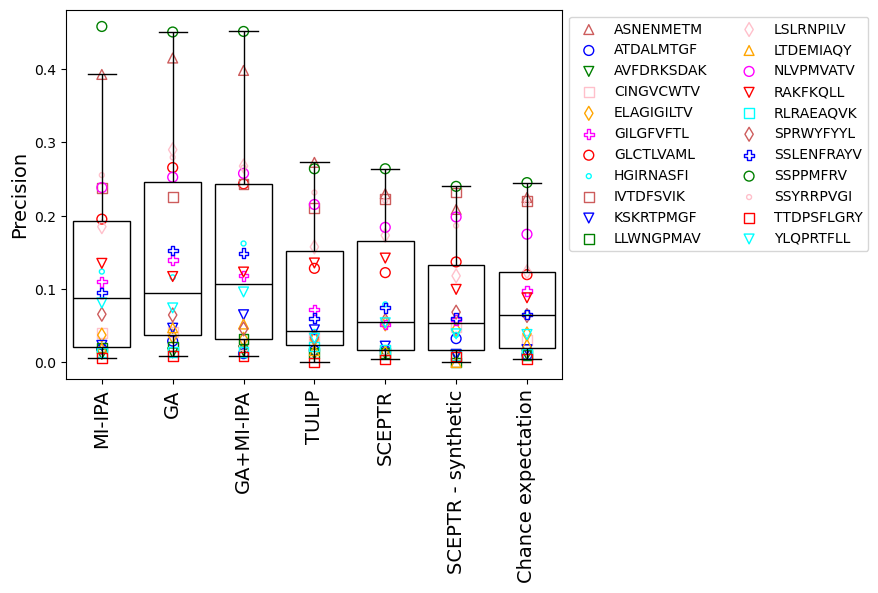

In [13]:
PROPS = {
    'boxprops':{'facecolor':'none', 'edgecolor':'k'},
    'medianprops':{'color':'k'},
    'whiskerprops':{'color':'k'},
    'capprops':{'color':'k'}
}

ax = plt.subplot()
for i in range(len(eps)):
    ax.scatter(all_results.loc[all_results['epitope'] == eps[i]]['variable'], 
                all_results.loc[all_results['epitope'] == eps[i]]['value'],  
                color=colors[i], marker = symbols[i], fc = 'none', s = 50, label = eps[i])
sns.boxplot(all_results, 
            x = 'variable', y = 'value', showfliers=False,
            ax=ax, **PROPS)
order = ['MI-IPA', 'GA', 'GA+MI-IPA', 'TULIP', 'SCEPTR', 'SCEPTR - synthetic', 'Chance expectation']
pairs = [('MI-IPA', 'Chance expectation'), ('GA', 'Chance expectation'), ('GA+MI-IPA', 'Chance expectation'),
         ('TULIP', 'Chance expectation'), ('SCEPTR', 'Chance expectation'), ('SCEPTR - synthetic', 'Chance expectation'),]
for p1,p2 in pairs:
    r1 = all_results.loc[all_results['variable'] == p1]['value']
    r2 = all_results.loc[all_results['variable'] == p2]['value']
    res = mannwhitneyu(r1, r2, alternative='greater')
    print(p1, p2, res.pvalue)
ax.legend(ncols = 2, bbox_to_anchor = [1,1], loc = 'upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation = 90, fontsize = 14)
ax.set_ylabel('Precision', fontsize = 14)
ax.set_xlabel('')
plt.savefig(f2 + 'benchmarking_summary_plot.pdf', bbox_inches = 'tight')
plt.show()